# Exercise 1
Given the following dataframe of sales transactions

In [51]:
import pandas as pd
import numpy as np

data = {
    "date": [
        "2023-05-01", "2023-05-02",
        "2023-05-05", "2023-05-07",
        "2023-05-10", "2023-05-15",
        "2023-05-20", "2023-05-25",
        "2023-05-30", "2023-05-31"
    ],
    "sales_amount": [100, 150, 200, 130, 180, 250, 300, 220, 270, 310]
}

df = pd.DataFrame(data)

1.  create a new column with the number of days since the last sales
2. add missing dates, filling missing values for sales_amount with 0
3. create a new column with the sale amount of 7 days before
4. create a new column with the mean amount of sales for the previous 7 days
5. convert the frequency to weekly, summing the sales for each week

In [52]:
df

,date,sales_amount
0,2023-05-01,100
1,2023-05-02,150
2,2023-05-05,200
3,2023-05-07,130
4,2023-05-10,180
5,2023-05-15,250
6,2023-05-20,300
7,2023-05-25,220
8,2023-05-30,270
9,2023-05-31,310


1.	Creo la colonna `days_since_last_sale`: Conterrà la differenza tra la data di ciascuna vendita e quella precedente con diff().
* converto la colonna date in formato `datetime`
* calcolo la differenza con `diff` mostrando il risultato in giorno con `dt.days`


In [53]:
# 1. Creare una nuova colonna con il numero di giorni dall'ultima vendita
df['date'] = pd.to_datetime(df['date']) 
df['days_since_last_sale'] = df['date'].diff().fillna(pd.Timedelta(0)).dt.days

In [54]:
df.head()

,date,sales_amount,days_since_last_sale
0,2023-05-01,100,0
1,2023-05-02,150,1
2,2023-05-05,200,3
3,2023-05-07,130,2
4,2023-05-10,180,3


2. Aggiungere le date mancanti, riempiendo i valori di `sales_amount` con 0
* `pd.date_range()` crea tutte le date comprese tra la data minima e quella massima del DataFrame.
* `reindex()` per aggiungere le date mancanti.
* Per le fate aggiunte uso `fill_value=0` che imposta i valori di `sales_amount` a 0.

In [55]:
# 2. Aggiungere le date mancanti, riempiendo i valori di sales_amount con 0
full_date_range = pd.date_range(df['date'].min(), df['date'].max())
df_full = df.set_index('date').reindex(full_date_range, fill_value=0)
df_full.index.name = 'date'

In [56]:
df_full.head()

,sales_amount,days_since_last_sale
date,,
2023-05-01,100,0
2023-05-02,150,1
2023-05-03,0,0
2023-05-04,0,0
2023-05-05,200,3


3. Creare una nuova colonna con il valore di vendita di 7 giorni prima
* Posso usare il metodo `shift` sul `sales_amount` con parametro `7` per ottenere il valore di vendita

In [57]:
# 3. Creare una nuova colonna con il valore di vendita di 7 giorni prima
df_full['sales_7_days_ago'] = df_full['sales_amount'].shift(7).fillna(0)

In [58]:
df_full.head()

,sales_amount,days_since_last_sale,sales_7_days_ago
date,,,
2023-05-01,100,0,0.0
2023-05-02,150,1,0.0
2023-05-03,0,0,0.0
2023-05-04,0,0,0.0
2023-05-05,200,3,0.0


4. Creare una nuova colonna con la media delle vendite degli ultimi 7 giorni
* `rolling()` per creare una finestra di 7 giorni
* `mean()` calcola la media 

In [59]:
# 4. Creare una nuova colonna con la media delle vendite degli ultimi 7 giorni
df_full['mean_sales_7_days'] = df_full['sales_amount'].rolling(7).mean().fillna(0)

In [63]:
df_full

,sales_amount,days_since_last_sale,sales_7_days_ago,mean_sales_7_days
date,,,,
2023-05-01,100,0,0.0,0.000000
2023-05-02,150,1,0.0,0.000000
2023-05-03,0,0,0.0,0.000000
2023-05-04,0,0,0.0,0.000000
2023-05-05,200,3,0.0,0.000000
2023-05-06,0,0,0.0,0.000000
2023-05-07,130,2,0.0,82.857143
2023-05-08,0,0,100.0,68.571429
2023-05-09,0,0,150.0,47.142857


5. Convertire la frequenza in settimanale, sommando le vendite per ogni settimana
Per aggregare i dati settimanali `resample('W')`

In [61]:
# 5. Convertire la frequenza in settimanale, sommando le vendite per ogni settimana
df_weekly_sales = df_full.resample('W').sum()


In [62]:
df_weekly_sales

,sales_amount,days_since_last_sale,sales_7_days_ago,mean_sales_7_days
date,,,,
2023-05-07,580,6,0.0,82.857143
2023-05-14,180,3,580.0,375.714286
2023-05-21,550,10,180.0,387.142857
2023-05-28,220,5,550.0,340.000000
2023-06-04,580,6,0.0,215.714286


# Exercise 2
Given the following sales data


Use the appropriate Exponential Smoothing model to forecast sales for the following 7 days.<br>

**Bonus**: plot the historical data and the generated forecast.

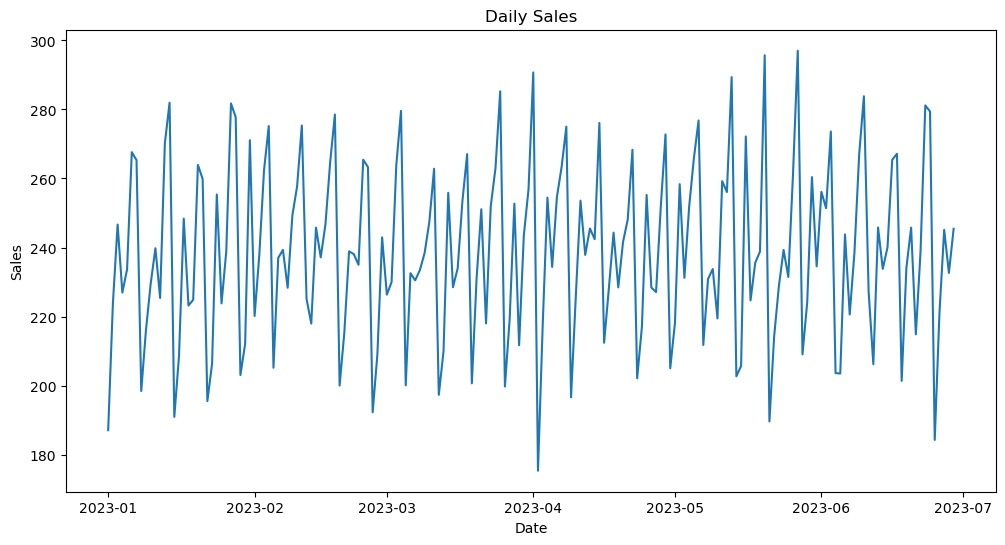

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

date_range = pd.date_range(start="2023-01-01", periods=180, freq="D")
values = np.array([200, 220, 250, 230, 240, 260, 280], dtype=float)
sales = np.tile(values, len(date_range) // 7 + 1)[:len(date_range)]
sales += np.random.normal(0, 10, len(sales))
df = pd.DataFrame({"date": date_range, "sales": sales})
df.set_index("date", inplace=True)

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x=df.index, y="sales")
plt.title("Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [25]:
df

,sales
date,
2023-01-01,187.082030
2023-01-02,223.774934
2023-01-03,246.653676
2023-01-04,226.951136
2023-01-05,233.659297
...,...
2023-06-25,184.254127
2023-06-26,221.036348
2023-06-27,245.107498


In [92]:
df.tail()

,sales
date,
2023-06-25,200.493711
2023-06-26,225.114745
2023-06-27,228.356137
2023-06-28,227.760865
2023-06-29,232.686348


## Applico la decomposizione
Uso la decomposizione per vedere meglio visivamente tutti i componenti (trend, stagionalità e residuo)

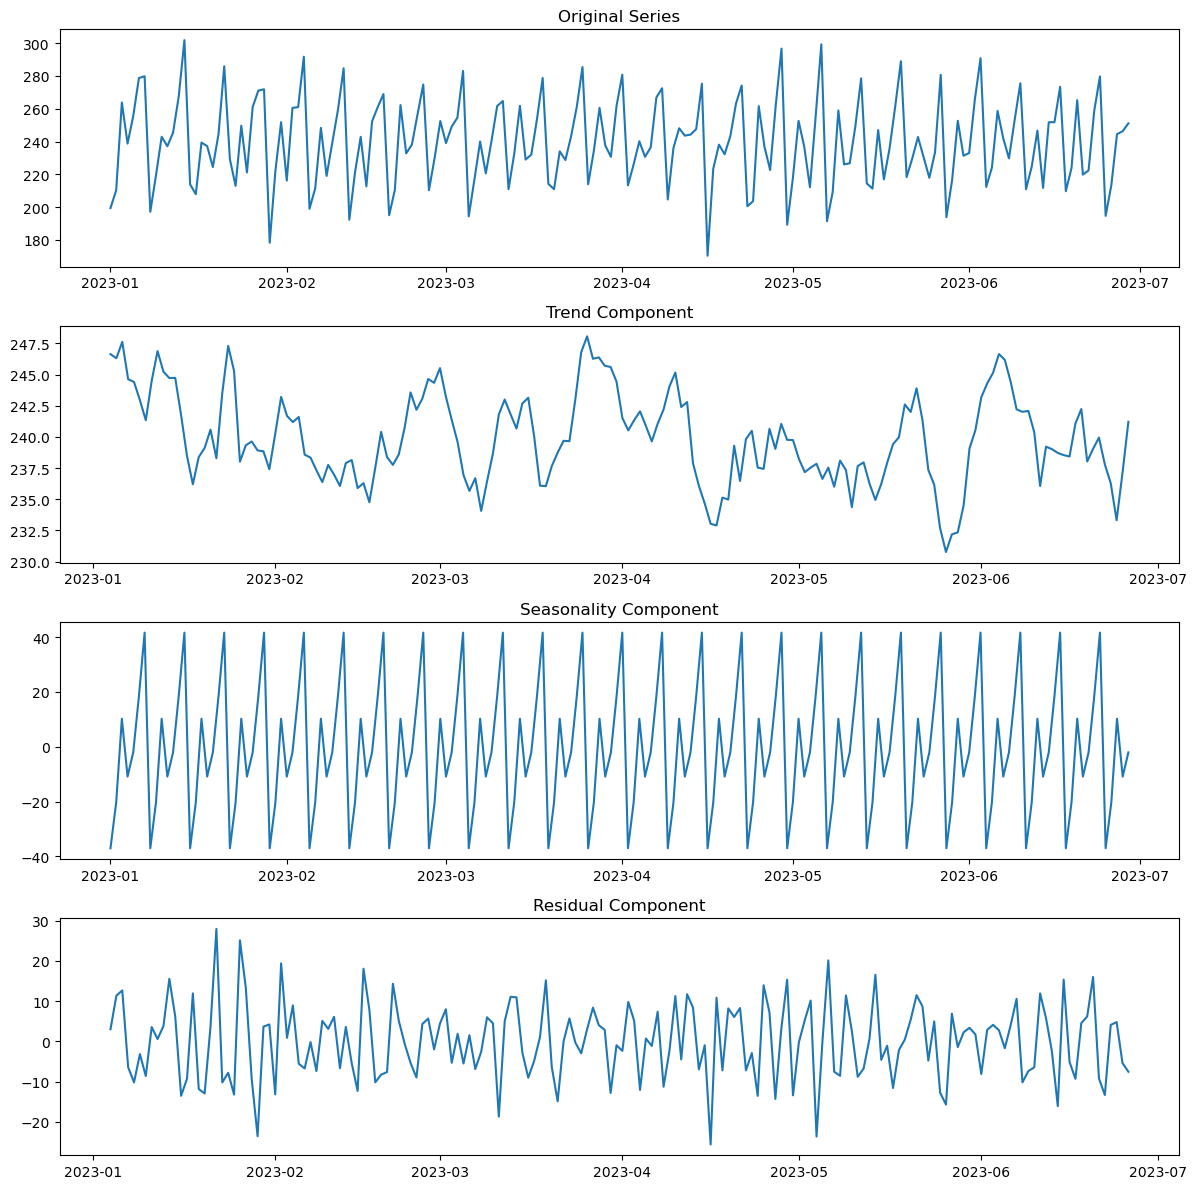

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

df.index = pd.to_datetime(df.index)  # Assicurati che l'indice sia datetime
df = df.asfreq('D')  # Imposta la frequenza giornaliera (se non è già giornaliera)

# Decomposizione della serie temporale
decomposition = seasonal_decompose(df['sales'], model='additive', period=7)

# Visualizzazione della decomposizione
plt.figure(figsize=(12, 12))
plt.subplot(411)
plt.plot(df['sales'], label='Original Series')
plt.title('Original Series')
plt.subplot(412)
plt.plot(decomposition.trend, label='Trend')
plt.title('Trend Component')
plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonality')
plt.title('Seasonality Component')
plt.subplot(414)
plt.plot(decomposition.resid, label='Residuals')
plt.title('Residual Component')
plt.tight_layout()
plt.show()

In [20]:
# Verifico se è stazionaria o meno
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['sales'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

if result[1] < 0.05:
    print("La serie è stazionaria")
else:
    print("La serie non è stazionaria")

ADF Statistic: -3.9044785008284206
p-value: 0.002002133909981675
La serie è stazionaria


Userò un **exponeatial smoothing**.

Uno dei modelli più comuni di esponenziale smoothing è il Simple Exponential Smoothing (SES), che però si usa in serie senza trend e senza stagionalità. 

Ma in questo caso abbiamo trend e stagionalità (che mi sembra costante ogni settimana, quindi userò il metodo additivo) quindi è meglio suare **Holt-winters**

In [8]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Applicazione del modello Holt-Winters (Exponential Smoothing)
model = ExponentialSmoothing(df['sales'], trend='add', seasonal='add', seasonal_periods=7)
fit_model = model.fit()

# Previsione per i prossimi 7 giorni
forecast = fit_model.forecast(steps=7)

# Visualizzazione del grafico con previsioni concatenate alla serie storica
forecast_index = pd.date_range(df.index[-1] + pd.Timedelta(days=1), periods=7, freq='D')

# Aggiungi le previsioni all'originale usando pd.concat()
forecast_df = pd.DataFrame({'sales': forecast}, index=forecast_index)
df_full = pd.concat([df, forecast_df])

df_full

,sales
2023-01-01,199.446009
2023-01-02,210.275121
2023-01-03,263.817501
2023-01-04,238.744956
2023-01-05,255.576876
...,...
2023-07-02,201.273899
2023-07-03,217.739859
2023-07-04,248.775760
2023-07-05,228.305260


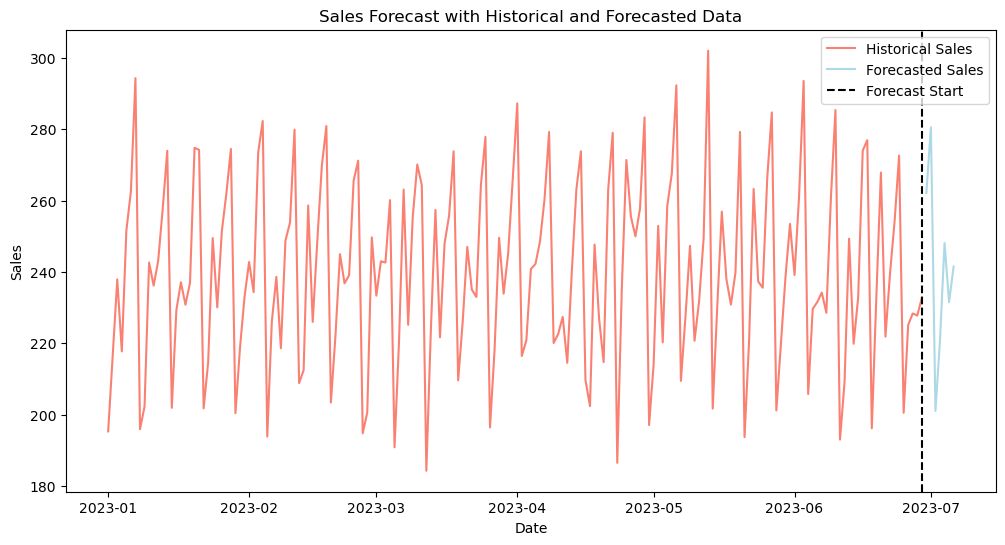

2023-06-30    262.131387
2023-07-01    280.551321
2023-07-02    201.015997
2023-07-03    220.786661
2023-07-04    248.090814
2023-07-05    231.490305
2023-07-06    241.507755
Freq: D, dtype: float64


In [88]:
# Creazione del grafico
plt.figure(figsize=(12, 6))

# Traccia i dati storici
sns.lineplot(data=df, x=df.index, y="sales", label="Historical Sales", color="salmon")

# Traccia le previsioni future
sns.lineplot(data=forecast_df, x=forecast_df.index, y="sales", label="Forecasted Sales", color="lightblue")

# Aggiungi una linea verticale per separare i dati storici dalle previsioni
plt.axvline(x=df.index[-1], color='black', linestyle='--', label="Forecast Start")

# Aggiungi il titolo, etichette e legenda
plt.title("Sales Forecast with Historical and Forecasted Data")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

# Mostra il grafico
plt.show()

# Visualizzazione delle 7 previsioni future
print(forecast)

In [9]:
df.tail(7)

,sales
date,
2023-06-23,258.841401
2023-06-24,279.730584
2023-06-25,194.662527
2023-06-26,213.326671
2023-06-27,244.475150
2023-06-28,246.343833
2023-06-29,251.109104


In [10]:
df_full.tail(7)

,sales
2023-06-30,257.043296
2023-07-01,280.084056
2023-07-02,201.273899
2023-07-03,217.739859
2023-07-04,248.775760
2023-07-05,228.305260
2023-07-06,236.933273


I risultati mi sembrano in linea con quelli della settimana precedente